In [1]:
# -*- coding: utf-8 -*-
"""
2026_HAI_MAE.ipynb

MAE (Masked Autoencoder) 제대로 된 구현
VAE 노트북과 동일한 환경/세팅으로 비교 실험

[VAE와 매칭한 세팅]
- batch_size = 64
- Transform: ToTensor()만 (정규화/aug 없음)
- Adam optimizer, lr=1e-3
- Pretrain 50 epoch, Linear probe 50 epoch
- Feature dim = 256 (embed_dim과 일치)
- CIFAR-10 표준 split 50k/10k

[MAE 고유 설정]
- Patch size = 4 (32x32 → 8x8 = 64 패치)
- Mask ratio = 0.75 (표준 MAE)
- Encoder: 4 layer Transformer, dim 256, head 8
- Decoder: 2 layer Transformer, dim 128, head 4
- Loss: 마스킹된 패치에만 MSE
"""

'\n2026_HAI_MAE.ipynb\n\nMAE (Masked Autoencoder) 제대로 된 구현\nVAE 노트북과 동일한 환경/세팅으로 비교 실험\n\n[VAE와 매칭한 세팅]\n- batch_size = 64\n- Transform: ToTensor()만 (정규화/aug 없음)\n- Adam optimizer, lr=1e-3\n- Pretrain 50 epoch, Linear probe 50 epoch\n- Feature dim = 256 (embed_dim과 일치)\n- CIFAR-10 표준 split 50k/10k\n\n[MAE 고유 설정]\n- Patch size = 4 (32x32 → 8x8 = 64 패치)\n- Mask ratio = 0.75 (표준 MAE)\n- Encoder: 4 layer Transformer, dim 256, head 8\n- Decoder: 2 layer Transformer, dim 128, head 4\n- Loss: 마스킹된 패치에만 MSE\n'

In [2]:
# ============================================
# Cell 1: Google Drive 마운트
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/vae_checkpoints'  # VAE랑 같은 폴더
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'mae_pretrained_v2.pth')  # 파일명만 다름
print(f"Checkpoint 경로: {CHECKPOINT_PATH}")

Mounted at /content/drive
Checkpoint 경로: /content/drive/MyDrive/vae_checkpoints/mae_pretrained_v2.pth


In [3]:
# ============================================
# Cell 2: CIFAR-10 데이터셋 (VAE와 동일)
# ============================================
import torch
import torchvision
import torchvision.transforms as tr
from torch.utils.data import DataLoader

transf = tr.Compose([tr.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transf)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transf)

batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:06<00:00, 25.7MB/s]


In [4]:
# ============================================
# Cell 3: MAE 모델 정의
# ============================================
import torch.nn as nn
import torch.nn.functional as F


class CustomMAE(nn.Module):
    """
    Masked Autoencoder
    - 입력 이미지를 패치로 나눠 75% 마스킹 → 가시 패치로 인코딩 → 디코더로 마스킹 영역 복원
    - 픽셀 단위 MSE loss (마스킹된 패치에만 적용)
    """
    def __init__(self, img_size=32, patch_size=4, in_chans=3,
                 embed_dim=256, decoder_embed_dim=128,
                 num_layers=4, num_heads=8,
                 decoder_num_layers=2, decoder_num_heads=4,
                 mask_ratio=0.75):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 64
        self.mask_ratio = mask_ratio
        self.in_chans = in_chans

        # ----- Patch Embedding -----
        # 32x32 이미지 → 4x4 패치 × 64개, 각 패치 → 256차원 벡터
        self.patch_embed = nn.Conv2d(in_chans, embed_dim,
                                     kernel_size=patch_size, stride=patch_size)

        # ----- Encoder Positional Embedding -----
        # Transformer는 위치 정보 없으므로 학습 가능한 pos embed 추가
        self.encoder_pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, embed_dim)
        )

        # ----- Encoder (Transformer 4 layer) -----
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ----- Encoder → Decoder 차원 변환 -----
        self.encoder_to_decoder = nn.Linear(embed_dim, decoder_embed_dim)

        # ----- Mask Token + Decoder Positional Embedding -----
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, decoder_embed_dim)
        )

        # ----- Decoder (Transformer 2 layer, 더 가벼움) -----
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_embed_dim, nhead=decoder_num_heads, batch_first=True
        )
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=decoder_num_layers)

        # ----- 최종 픽셀 예측 헤드 -----
        # decoder 출력(128) → 패치 픽셀(4*4*3 = 48)
        self.head = nn.Linear(decoder_embed_dim, patch_size * patch_size * in_chans)

        # ----- 가중치 초기화 -----
        nn.init.trunc_normal_(self.encoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def patchify(self, imgs):
        """[B, 3, 32, 32] → [B, 64, 48] (loss 계산용 target)"""
        p = self.patch_size
        h = w = imgs.shape[2] // p
        x = imgs.reshape(imgs.shape[0], 3, h, p, w, p)
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(imgs.shape[0], h * w, p * p * 3)
        return x

    def unpatchify(self, x):
        """[B, 64, 48] → [B, 3, 32, 32] (시각화용)"""
        p = self.patch_size
        h = w = int(x.shape[1] ** 0.5)
        x = x.reshape(x.shape[0], h, w, p, p, 3)
        x = torch.einsum('nhwpqc->nchpwq', x)
        x = x.reshape(x.shape[0], 3, h * p, w * p)
        return x

    def random_masking(self, x, mask_ratio):
        """
        패치 중 mask_ratio 비율을 무작위로 제거
        Returns:
            x_kept: 가시 패치만 [B, len_keep, D]
            mask: 마스킹 위치 (1=masked, 0=visible) [B, L]
            ids_restore: 원래 순서 복원용 인덱스 [B, L]
        """
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))

        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # 앞 len_keep개만 유지
        ids_keep = ids_shuffle[:, :len_keep]
        x_kept = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        # 이진 마스크 생성 (loss 계산용)
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_kept, mask, ids_restore

    def forward_encoder(self, x, mask_ratio):
        # 패치 임베딩
        x = self.patch_embed(x).flatten(2).transpose(1, 2)  # [B, 64, 256]
        # Positional embedding (마스킹 전에 추가)
        x = x + self.encoder_pos_embed
        # 마스킹
        x_kept, mask, ids_restore = self.random_masking(x, mask_ratio)
        # 인코더 통과 (가시 패치만)
        x_kept = self.encoder(x_kept)
        return x_kept, mask, ids_restore

    def forward_decoder(self, x_kept, ids_restore):
        # 차원 변환
        x = self.encoder_to_decoder(x_kept)  # [B, len_keep, 128]
        # Mask token 결합
        num_mask = ids_restore.shape[1] - x.shape[1]
        mask_tokens = self.mask_token.repeat(x.shape[0], num_mask, 1)
        x_ = torch.cat([x, mask_tokens], dim=1)
        # 원래 순서로 복원 (unshuffle)
        x_ = torch.gather(x_, dim=1,
                         index=ids_restore.unsqueeze(-1).repeat(1, 1, x_.shape[2]))
        # Decoder pos embedding 추가
        x_ = x_ + self.decoder_pos_embed
        # 디코더 통과
        x_ = self.decoder(x_)
        # 픽셀 예측
        pred = self.head(x_)  # [B, 64, 48]
        return pred

    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)

        # ⭐ 추가: Per-patch normalization
        mean = target.mean(dim=-1, keepdim=True)
        var = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6) ** 0.5

        loss = ((pred - target) ** 2).mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss

    def forward(self, imgs):
        x_kept, mask, ids_restore = self.forward_encoder(imgs, self.mask_ratio)
        pred = self.forward_decoder(x_kept, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask

In [5]:
# ============================================
# Cell 4: 1단계 - MAE 사전학습 (체크포인트 저장)
# ============================================
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

mae_model = CustomMAE(img_size=32, patch_size=4, embed_dim=256,
                       decoder_embed_dim=128, num_layers=4, num_heads=8,
                       decoder_num_layers=2, decoder_num_heads=4,
                       mask_ratio=0.75).to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in mae_model.parameters())
encoder_params = sum(p.numel() for p in mae_model.encoder.parameters()) \
               + sum(p.numel() for p in mae_model.patch_embed.parameters()) \
               + mae_model.encoder_pos_embed.numel()
print(f"MAE 전체 파라미터: {total_params:,}")
print(f"MAE encoder 파라미터: {encoder_params:,}")

pretrain_loss_history = []

# 저장된 모델 있으면 로드
if os.path.exists(CHECKPOINT_PATH):
    print("✅ 저장된 사전학습 모델 발견! 로드합니다.")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    mae_model.load_state_dict(checkpoint['model_state_dict'])
    pretrain_loss_history = checkpoint['loss_history']
    print(f"   - 마지막 epoch loss: {pretrain_loss_history[-1]:.4f}")
else:
    print("📚 사전학습 시작...")
    optimizer = optim.AdamW(mae_model.parameters(), lr=1.5e-4, weight_decay=0.05)
    pretrain_epochs = 50  # VAE와 동일

    for epoch in range(pretrain_epochs):
        mae_model.train()
        running_loss = 0.0
        for images, _ in trainloader:  # 라벨 사용 X (unsupervised)
            images = images.to(device)

            optimizer.zero_grad()
            loss, pred, mask = mae_model(images)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(trainloader)
        pretrain_loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{pretrain_epochs}], Loss: {avg_loss:.4f}")

        # 10 epoch마다 중간 저장
        if (epoch + 1) % 10 == 0:
            torch.save({
                'model_state_dict': mae_model.state_dict(),
                'loss_history': pretrain_loss_history,
                'epoch': epoch + 1
            }, CHECKPOINT_PATH)
            print(f"   💾 중간 저장 완료 (epoch {epoch+1})")

    # 최종 저장
    torch.save({
        'model_state_dict': mae_model.state_dict(),
        'loss_history': pretrain_loss_history,
        'epoch': pretrain_epochs
    }, CHECKPOINT_PATH)
    print(f"✅ 사전학습 완료 & 저장: {CHECKPOINT_PATH}")

Device: cuda
MAE 전체 파라미터: 6,522,672
MAE encoder 파라미터: 5,289,216
📚 사전학습 시작...
Epoch [1/50], Loss: 0.7785
Epoch [2/50], Loss: 0.7123
Epoch [3/50], Loss: 0.6674
Epoch [4/50], Loss: 0.6282
Epoch [5/50], Loss: 0.6027
Epoch [6/50], Loss: 0.5863
Epoch [7/50], Loss: 0.5746
Epoch [8/50], Loss: 0.5656
Epoch [9/50], Loss: 0.5584
Epoch [10/50], Loss: 0.5523
   💾 중간 저장 완료 (epoch 10)
Epoch [11/50], Loss: 0.5473
Epoch [12/50], Loss: 0.5424
Epoch [13/50], Loss: 0.5387
Epoch [14/50], Loss: 0.5351
Epoch [15/50], Loss: 0.5324
Epoch [16/50], Loss: 0.5298
Epoch [17/50], Loss: 0.5268
Epoch [18/50], Loss: 0.5243
Epoch [19/50], Loss: 0.5225
Epoch [20/50], Loss: 0.5201
   💾 중간 저장 완료 (epoch 20)
Epoch [21/50], Loss: 0.5186
Epoch [22/50], Loss: 0.5169
Epoch [23/50], Loss: 0.5150
Epoch [24/50], Loss: 0.5139
Epoch [25/50], Loss: 0.5126
Epoch [26/50], Loss: 0.5115
Epoch [27/50], Loss: 0.5093
Epoch [28/50], Loss: 0.5085
Epoch [29/50], Loss: 0.5075
Epoch [30/50], Loss: 0.5064
   💾 중간 저장 완료 (epoch 30)
Epoch [31/50], Lo

In [6]:
# ============================================
# Cell 5: 2단계 - Linear Probing
# ============================================

# Encoder freeze
for param in mae_model.parameters():
    param.requires_grad = False


class MAELinearProbingModel(nn.Module):
    """
    [중요] Linear probe 시에는 마스킹 X (전체 패치 사용)
    - Patch embed + pos embed + encoder 통과
    - Global Average Pooling으로 256차원 feature 추출
    """
    def __init__(self, pretrained_mae, embed_dim=256, num_classes=10):
        super().__init__()
        self.pretrained_mae = pretrained_mae
        self.pretrained_mae.eval()
        self.classifier = nn.Linear(embed_dim, num_classes)

    def train(self, mode=True):
        super().train(mode)
        self.pretrained_mae.eval()  # MAE는 항상 eval
        return self

    def forward(self, x):
        with torch.no_grad():
            # 1. 패치 임베딩
            x = self.pretrained_mae.patch_embed(x).flatten(2).transpose(1, 2)
            # 2. Pos embedding 추가
            x = x + self.pretrained_mae.encoder_pos_embed
            # 3. 인코더 통과 (마스킹 X, 전체 패치 사용)
            features = self.pretrained_mae.encoder(x)  # [B, 64, 256]
            # 4. Global Average Pooling
            features = features.mean(dim=1)  # [B, 256]
        return self.classifier(features)


probing_model = MAELinearProbingModel(mae_model, embed_dim=256).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(probing_model.classifier.parameters(), lr=1e-3)

probe_epochs = 50
probe_loss_history = []

print("\n--- 2단계: 선형 분류기 학습 시작 ---")
for epoch in range(probe_epochs):
    probing_model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = probing_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    probe_loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{probe_epochs}], Loss: {avg_loss:.4f}")


--- 2단계: 선형 분류기 학습 시작 ---
Epoch [1/50], Loss: 1.4834
Epoch [2/50], Loss: 1.2580
Epoch [3/50], Loss: 1.2081
Epoch [4/50], Loss: 1.1803
Epoch [5/50], Loss: 1.1609
Epoch [6/50], Loss: 1.1457
Epoch [7/50], Loss: 1.1335
Epoch [8/50], Loss: 1.1237
Epoch [9/50], Loss: 1.1157
Epoch [10/50], Loss: 1.1079
Epoch [11/50], Loss: 1.1017
Epoch [12/50], Loss: 1.0947
Epoch [13/50], Loss: 1.0904
Epoch [14/50], Loss: 1.0844
Epoch [15/50], Loss: 1.0803
Epoch [16/50], Loss: 1.0764
Epoch [17/50], Loss: 1.0725
Epoch [18/50], Loss: 1.0695
Epoch [19/50], Loss: 1.0661
Epoch [20/50], Loss: 1.0618
Epoch [21/50], Loss: 1.0592
Epoch [22/50], Loss: 1.0565
Epoch [23/50], Loss: 1.0538
Epoch [24/50], Loss: 1.0508
Epoch [25/50], Loss: 1.0486
Epoch [26/50], Loss: 1.0466
Epoch [27/50], Loss: 1.0443
Epoch [28/50], Loss: 1.0421
Epoch [29/50], Loss: 1.0397
Epoch [30/50], Loss: 1.0378
Epoch [31/50], Loss: 1.0360
Epoch [32/50], Loss: 1.0342
Epoch [33/50], Loss: 1.0328
Epoch [34/50], Loss: 1.0306
Epoch [35/50], Loss: 1.0302
Ep

In [7]:
# ============================================
# Cell 6: 3단계 - 분류 정확도 측정
# ============================================
print("\n--- 3단계: 성능 평가 ---")
probing_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = probing_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"MAE Linear Probing 최종 분류 정확도: {accuracy:.2f}%")


--- 3단계: 성능 평가 ---
MAE Linear Probing 최종 분류 정확도: 63.00%


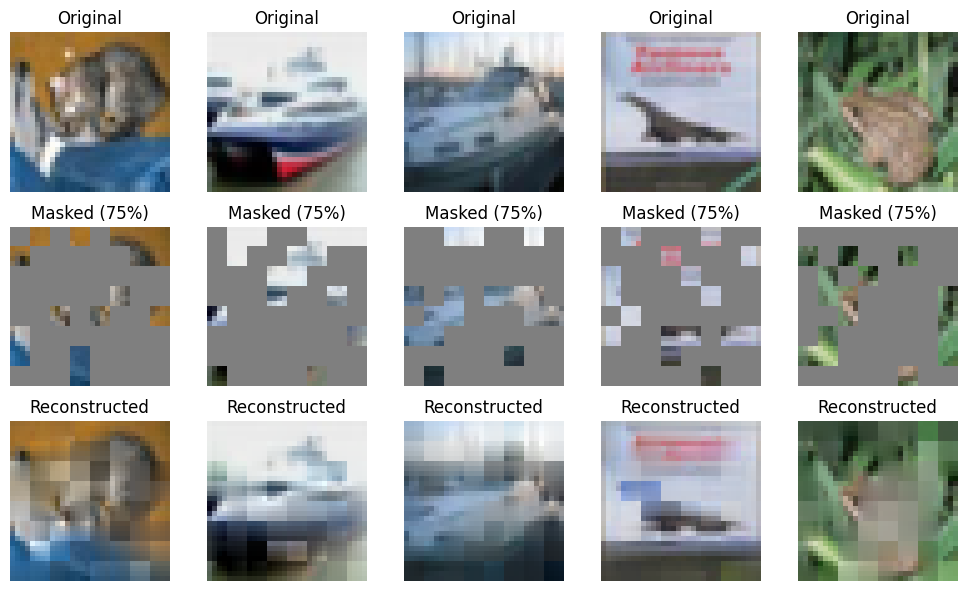

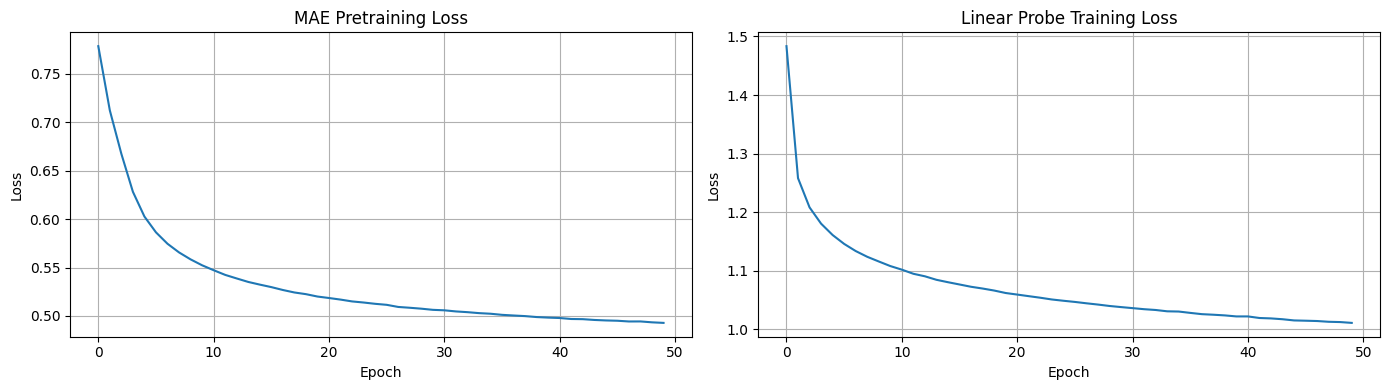

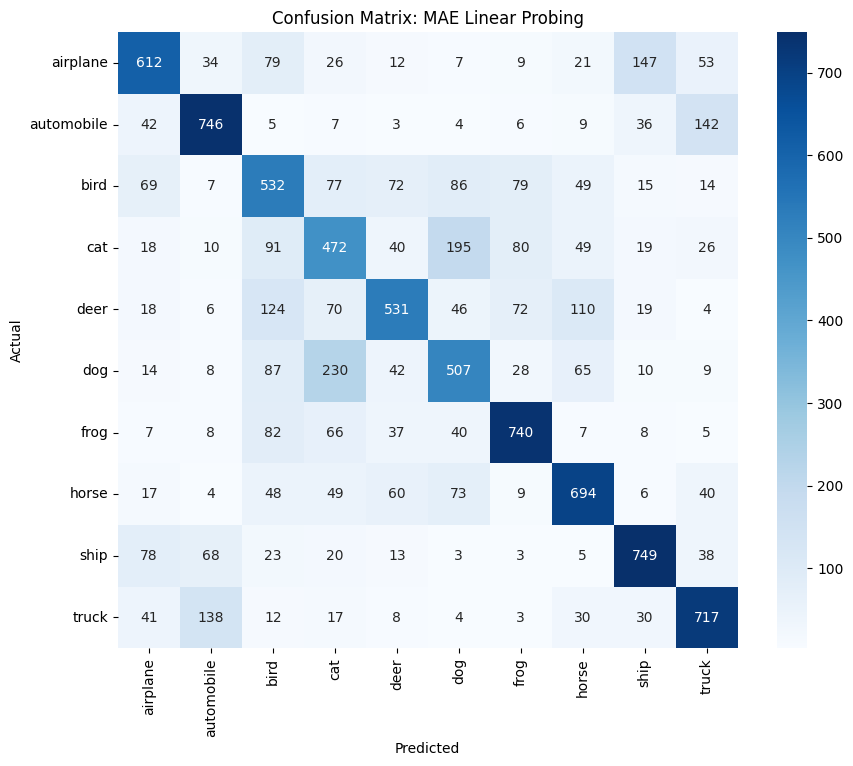

In [8]:
# ============================================
# Cell 7: 시각화 (복원, Loss 곡선, Confusion Matrix)
# ============================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. 이미지 복원 시각화 (MAE 스타일: 원본 / 마스킹된 입력 / 복원)
mae_model.eval()
with torch.no_grad():
    images, _ = next(iter(testloader))
    images = images.to(device)

    # 1. encoder + decoder 직접 호출 (loss 계산 안 함)
    x_kept, mask, ids_restore = mae_model.forward_encoder(images, mae_model.mask_ratio)
    pred = mae_model.forward_decoder(x_kept, ids_restore)

    # 2. ⭐ pred는 normalized space → 역정규화 필요
    target = mae_model.patchify(images)
    mean = target.mean(dim=-1, keepdim=True)
    var = target.var(dim=-1, keepdim=True)
    pred_unnorm = pred * (var + 1e-6) ** 0.5 + mean

    # 3. 시각화
    mask_expanded = mask.unsqueeze(-1)
    masked_input = target * (1 - mask_expanded) + 0.5 * mask_expanded
    masked_input = mae_model.unpatchify(masked_input)

    combined = target * (1 - mask_expanded) + pred_unnorm * mask_expanded  # ← 역정규화한 거 사용
    recon = mae_model.unpatchify(combined)
    recon = torch.clamp(recon, 0, 1)

plt.figure(figsize=(10, 6))
for i in range(5):
    # 원본
    plt.subplot(3, 5, i + 1)
    plt.imshow(np.transpose(images[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Original"); plt.axis('off')
    # 마스킹된 입력
    plt.subplot(3, 5, i + 6)
    plt.imshow(np.transpose(masked_input[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Masked (75%)"); plt.axis('off')
    # 복원
    plt.subplot(3, 5, i + 11)
    plt.imshow(np.transpose(recon[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Reconstructed"); plt.axis('off')
plt.tight_layout(); plt.show()

# 2. Loss 곡선 (사전학습 + linear probe)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(pretrain_loss_history)
axes[0].set_title("MAE Pretraining Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(True)
axes[1].plot(probe_loss_history)
axes[1].set_title("Linear Probe Training Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].grid(True)
plt.tight_layout(); plt.show()

# 3. Confusion Matrix
all_preds, all_labels = [], []
probing_model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = probing_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
classes = trainset.classes
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix: MAE Linear Probing")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()